# Multimodal Intent Recognition and OOD Detection  
## Hinglish Talk-Show Dialogue (The Kapil Sharma Show)

**Dataset**: 324 utterances · 18 intent classes · 128 OOD samples  
**Text**: MuRIL (Multilingual Representations for Indian Languages)  
**Audio**: WavLM  
**Method**: Weighted multimodal fusion + Mahalanobis OOD detection  
**Inspired by**: MIntOOD (Zhang et al., IEEE TMM 2025)

In [1]:
# ── install dependencies ───────────────────────────────
!pip install transformers torchaudio -q

In [2]:
import os
import pandas as pd

base = "/kaggle/input/datasets/kromniscient/hinglish-intent-ood-data/"
clip_dir = base + "Scenes/Scenes/"

df = pd.read_csv(base + "Dataset - Transcript.csv")
df.columns = df.columns.str.strip()
df["Label"] = df["Label"].str.strip().str.lower()

# drop missing clips
df["clip_exists"] = df["Video ID"].apply(
    lambda x: os.path.exists(clip_dir + str(x) + ".mp4")
)
df = df[df["clip_exists"]].reset_index(drop=True)
print("Dataset ready:", len(df), "rows")

Dataset ready: 324 rows


In [3]:
import torch
import torchaudio
import numpy as np
from transformers import AutoTokenizer, AutoModel, WavLMModel, AutoProcessor
import subprocess, os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

base = "/kaggle/input/datasets/kromniscient/hinglish-intent-ood-data/"
clip_dir = base + "Scenes/Scenes/"
out_dir = "/kaggle/working/"

# ── STEP 1: TEXT FEATURES (MuRIL) ─────────────────────
print("\nLoading MuRIL...")
tokenizer = AutoTokenizer.from_pretrained("google/muril-base-cased")
text_model = AutoModel.from_pretrained("google/muril-base-cased").to(device)
text_model.eval()

text_feats = []
for i, text in enumerate(df["Hinglish Text"]):
    inputs = tokenizer(str(text), return_tensors="pt",
                       truncation=True, max_length=128,
                       padding=True).to(device)
    with torch.no_grad():
        out = text_model(**inputs)
    feat = out.last_hidden_state[:, 0, :].squeeze().cpu().numpy()
    text_feats.append(feat)
    if (i+1) % 50 == 0:
        print(f"  Text: {i+1}/{len(df)} done")

text_feats = np.array(text_feats)
np.save(out_dir + "text_feats.npy", text_feats)
print("Text features saved:", text_feats.shape)

Using device: cuda

Loading MuRIL...


config.json:   0%|          | 0.00/411 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/206 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/113 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/953M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/953M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: google/muril-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Text: 50/324 done
  Text: 100/324 done
  Text: 150/324 done
  Text: 200/324 done
  Text: 250/324 done
  Text: 300/324 done
Text features saved: (324, 768)


In [4]:
# ── STEP 2: AUDIO FEATURES (WavLM) ────────────────────
import subprocess

from transformers import AutoFeatureExtractor, WavLMModel

print("Loading WavLM...")
processor = AutoFeatureExtractor.from_pretrained("microsoft/wavlm-base")
wavlm = WavLMModel.from_pretrained("microsoft/wavlm-base").to(device)
wavlm.eval()
audio_feats = []
failed = []

for i, vid_id in enumerate(df["Video ID"]):
    mp4_path = clip_dir + str(vid_id) + ".mp4"
    wav_path = f"/kaggle/working/temp_{i}.wav"
    
    # extract audio from mp4
    subprocess.run([
        "ffmpeg", "-i", mp4_path,
        "-ac", "1", "-ar", "16000",
        "-vn", wav_path,
        "-y", "-loglevel", "error"
    ])
    
    try:
        wav, sr = torchaudio.load(wav_path)
        if sr != 16000:
            wav = torchaudio.functional.resample(wav, sr, 16000)
        
        inputs = processor(wav.squeeze().numpy(), 
                          sampling_rate=16000,
                          return_tensors="pt").to(device)
        with torch.no_grad():
            out = wavlm(**inputs)
        feat = out.last_hidden_state.mean(dim=1).squeeze().cpu().numpy()
        audio_feats.append(feat)
        
        # clean up temp file
        os.remove(wav_path)
        
    except Exception as e:
        print(f"Failed on {vid_id}: {e}")
        failed.append(i)
        audio_feats.append(np.zeros(768))

audio_feats = np.array(audio_feats)
np.save("/kaggle/working/audio_feats.npy", audio_feats)
print("Audio features saved:", audio_feats.shape)
print("Failed clips:", len(failed))

Loading WavLM...


preprocessor_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/378M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/248 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/functional.py:6371: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(
/usr/local/lib/python3.12/dist-packages/torch/nn/functional.py:6371: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(
/usr/local/lib/python3.12/dist-packages/torch/nn/functional.py:6371: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(
/usr/local/lib/python3.12/dist-packages/torch/nn/functional.py:6371: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(
/usr/local/lib/python3.12/dist-packages/torch/nn/functional.py:6371: UserWarning: Support for mismatched key_padding

Audio features saved: (324, 768)
Failed clips: 0


/usr/local/lib/python3.12/dist-packages/torch/nn/functional.py:6371: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(


In [5]:
# verify both files are saved
import os
print("text_feats:", os.path.getsize("/kaggle/working/text_feats.npy") / 1e6, "MB")
print("audio_feats:", os.path.getsize("/kaggle/working/audio_feats.npy") / 1e6, "MB")
print("labels:", df["Label"].value_counts()["other"], "OOD samples confirmed")

text_feats: 0.995456 MB
audio_feats: 0.995456 MB
labels: 128 OOD samples confirmed


In [6]:
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score
from scipy.spatial.distance import mahalanobis
from collections import Counter
import numpy.linalg as LA

# ── load features ──────────────────────────────────────
text_f  = np.load("/kaggle/working/text_feats.npy")
audio_f = np.load("/kaggle/working/audio_feats.npy")

# ── split OOD vs ID ────────────────────────────────────
ood_mask = df["Label"] == "other"
id_mask  = ~ood_mask

id_df    = df[id_mask].copy().reset_index(drop=True)
text_id  = text_f[id_mask]
audio_id = audio_f[id_mask]
text_ood  = text_f[ood_mask]
audio_ood = audio_f[ood_mask]

# ── drop rare classes ──────────────────────────────────
label_counts = Counter(id_df["Label"])
valid_labels = {l for l, c in label_counts.items() if c >= 3}
print("Removed:", {l for l, c in label_counts.items() if c < 3})

keep     = id_df["Label"].isin(valid_labels)
id_df    = id_df[keep].reset_index(drop=True)
text_id  = text_id[keep.values]
audio_id = audio_id[keep.values]

le = LabelEncoder()
labels = le.fit_transform(id_df["Label"])
n_classes = len(le.classes_)
print("Intent classes:", n_classes)
print("Training samples:", len(labels))
print("OOD samples:", len(text_ood))

# ── train/test split ───────────────────────────────────
X_t_tr, X_t_te, X_a_tr, X_a_te, y_tr, y_te = train_test_split(
    text_id, audio_id, labels,
    test_size=0.2, random_state=42
)
print(f"Train: {len(y_tr)} | Test: {len(y_te)}")

# ── dataset ────────────────────────────────────────────
class IntentDataset(Dataset):
    def __init__(self, t, a, y):
        self.t = torch.tensor(t, dtype=torch.float32)
        self.a = torch.tensor(a, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.t[i], self.a[i], self.y[i]

train_dl = DataLoader(IntentDataset(X_t_tr, X_a_tr, y_tr), batch_size=16, shuffle=True)
test_dl  = DataLoader(IntentDataset(X_t_te, X_a_te, y_te), batch_size=16)

# ── fusion model ───────────────────────────────────────
class FusionNet(nn.Module):
    def __init__(self, dim=768, hidden=256, n_cls=n_classes):
        super().__init__()
        self.enc_t = nn.Sequential(nn.Linear(dim, hidden), nn.ReLU(), nn.Dropout(0.3))
        self.enc_a = nn.Sequential(nn.Linear(dim, hidden), nn.ReLU(), nn.Dropout(0.3))
        self.w_t   = nn.Linear(hidden, 1)
        self.w_a   = nn.Linear(hidden, 1)
        self.classifier = nn.Linear(hidden, n_cls)

    def forward(self, t, a):
        ht = self.enc_t(t)
        ha = self.enc_a(a)
        weights = torch.softmax(
            torch.stack([self.w_t(ht), self.w_a(ha)], dim=1), dim=1)
        fused = weights[:,0]*ht + weights[:,1]*ha
        return self.classifier(fused), fused

model   = FusionNet().to(device)
opt     = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
loss_fn = nn.CrossEntropyLoss()

# ── training ───────────────────────────────────────────
print("\nTraining...")
for epoch in range(150):
    model.train()
    total_loss = 0
    for t, a, y in train_dl:
        t, a, y = t.to(device), a.to(device), y.to(device)
        logits, _ = model(t, a)
        loss = loss_fn(logits, y)
        opt.zero_grad(); loss.backward(); opt.step()
        total_loss += loss.item()
    if (epoch+1) % 25 == 0:
        print(f"Epoch {epoch+1}/150  loss={total_loss/len(train_dl):.4f}")

# ── intent accuracy ────────────────────────────────────
print("\nEvaluating...")
model.eval()
preds, trues = [], []
for t, a, y in test_dl:
    with torch.no_grad():
        logits, _ = model(t.to(device), a.to(device))
    preds += logits.argmax(1).cpu().tolist()
    trues += y.tolist()
acc = accuracy_score(trues, preds)
print(f"Intent Accuracy: {acc*100:.1f}%")

# ── OOD via Mahalanobis ───────────────────────────────
print("Computing OOD scores...")
class_embeds = {c: [] for c in range(n_classes)}
for t, a, y in train_dl:
    with torch.no_grad():
        _, emb = model(t.to(device), a.to(device))
    for e, label in zip(emb.cpu().numpy(), y.numpy()):
        class_embeds[label].append(e)

means   = {c: np.mean(class_embeds[c], axis=0) for c in range(n_classes)}
all_emb = np.vstack(list(class_embeds.values()))
cov     = np.cov(all_emb.T) + np.eye(256)*1e-5
cov_inv = LA.inv(cov)

def maha_score(embed):
    return min(mahalanobis(embed, means[c], cov_inv) for c in range(n_classes))

with torch.no_grad():
    _, id_embs  = model(torch.tensor(X_t_te, dtype=torch.float32).to(device),
                        torch.tensor(X_a_te, dtype=torch.float32).to(device))
    _, ood_embs = model(torch.tensor(text_ood,  dtype=torch.float32).to(device),
                        torch.tensor(audio_ood, dtype=torch.float32).to(device))

id_scores  = [maha_score(e) for e in id_embs.cpu().numpy()]
ood_scores = [maha_score(e) for e in ood_embs.cpu().numpy()]

auroc = roc_auc_score([0]*len(id_scores) + [1]*len(ood_scores),
                       id_scores + ood_scores)
print(f"OOD AUROC: {auroc*100:.1f}%")

torch.save(model.state_dict(), "/kaggle/working/fusion_model.pt")
print("\nDone. Model saved.")

Removed: {'warn', 'prevent', 'ask for help', 'invite', 'thank', 'criticize', 'ask for opinions'}
Intent classes: 18
Training samples: 186
OOD samples: 128
Train: 148 | Test: 38

Training...
Epoch 25/150  loss=2.2787
Epoch 50/150  loss=1.9506
Epoch 75/150  loss=1.7551
Epoch 100/150  loss=1.5364
Epoch 125/150  loss=1.3339
Epoch 150/150  loss=1.1515

Evaluating...
Intent Accuracy: 31.6%
Computing OOD scores...
OOD AUROC: 62.3%

Done. Model saved.


In [7]:
# ── TEXT ONLY BASELINE (for ablation comparison) ──────
class TextOnlyNet(nn.Module):
    def __init__(self, dim=768, hidden=256, n_cls=n_classes):
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(dim, hidden), nn.ReLU(), nn.Dropout(0.3))
        self.classifier = nn.Linear(hidden, n_cls)

    def forward(self, t):
        h = self.enc(t)
        return self.classifier(h), h

text_model_only = TextOnlyNet().to(device)
opt2 = torch.optim.Adam(text_model_only.parameters(), lr=1e-4, weight_decay=1e-4)

print("Training text-only baseline...")
for epoch in range(150):
    text_model_only.train()
    total_loss = 0
    for t, a, y in train_dl:
        t, y = t.to(device), y.to(device)
        logits, _ = text_model_only(t)
        loss = loss_fn(logits, y)
        opt2.zero_grad(); loss.backward(); opt2.step()
        total_loss += loss.item()
    if (epoch+1) % 50 == 0:
        print(f"Epoch {epoch+1}/150  loss={total_loss/len(train_dl):.4f}")

# accuracy
text_model_only.eval()
preds2, trues2 = [], []
for t, a, y in test_dl:
    with torch.no_grad():
        logits, _ = text_model_only(t.to(device))
    preds2 += logits.argmax(1).cpu().tolist()
    trues2 += y.tolist()
acc2 = accuracy_score(trues2, preds2)
print(f"Text-only Intent Accuracy: {acc2*100:.1f}%")

# OOD
class_embeds2 = {c: [] for c in range(n_classes)}
for t, a, y in train_dl:
    with torch.no_grad():
        _, emb = text_model_only(t.to(device))
    for e, label in zip(emb.cpu().numpy(), y.numpy()):
        class_embeds2[label].append(e)

means2   = {c: np.mean(class_embeds2[c], axis=0) for c in range(n_classes)}
all_emb2 = np.vstack(list(class_embeds2.values()))
cov2     = np.cov(all_emb2.T) + np.eye(256)*1e-5
cov_inv2 = LA.inv(cov2)

def maha_score2(embed):
    return min(mahalanobis(embed, means2[c], cov_inv2) for c in range(n_classes))

with torch.no_grad():
    _, id_embs2  = text_model_only(torch.tensor(X_t_te, dtype=torch.float32).to(device))
    _, ood_embs2 = text_model_only(torch.tensor(text_ood, dtype=torch.float32).to(device))

id_scores2  = [maha_score2(e) for e in id_embs2.cpu().numpy()]
ood_scores2 = [maha_score2(e) for e in ood_embs2.cpu().numpy()]

auroc2 = roc_auc_score([0]*len(id_scores2) + [1]*len(ood_scores2),
                        id_scores2 + ood_scores2)
print(f"Text-only OOD AUROC: {auroc2*100:.1f}%")

print("\n── Ablation Summary ──────────────────")
print(f"Text only      →  Accuracy: {acc2*100:.1f}%  |  AUROC: {auroc2*100:.1f}%")
print(f"Text + Audio   →  Accuracy: {acc*100:.1f}%  |  AUROC: {auroc*100:.1f}%")

Training text-only baseline...
Epoch 50/150  loss=2.5486
Epoch 100/150  loss=2.4486
Epoch 150/150  loss=2.4573
Text-only Intent Accuracy: 23.7%
Text-only OOD AUROC: 51.5%

── Ablation Summary ──────────────────
Text only      →  Accuracy: 23.7%  |  AUROC: 51.5%
Text + Audio   →  Accuracy: 31.6%  |  AUROC: 62.3%


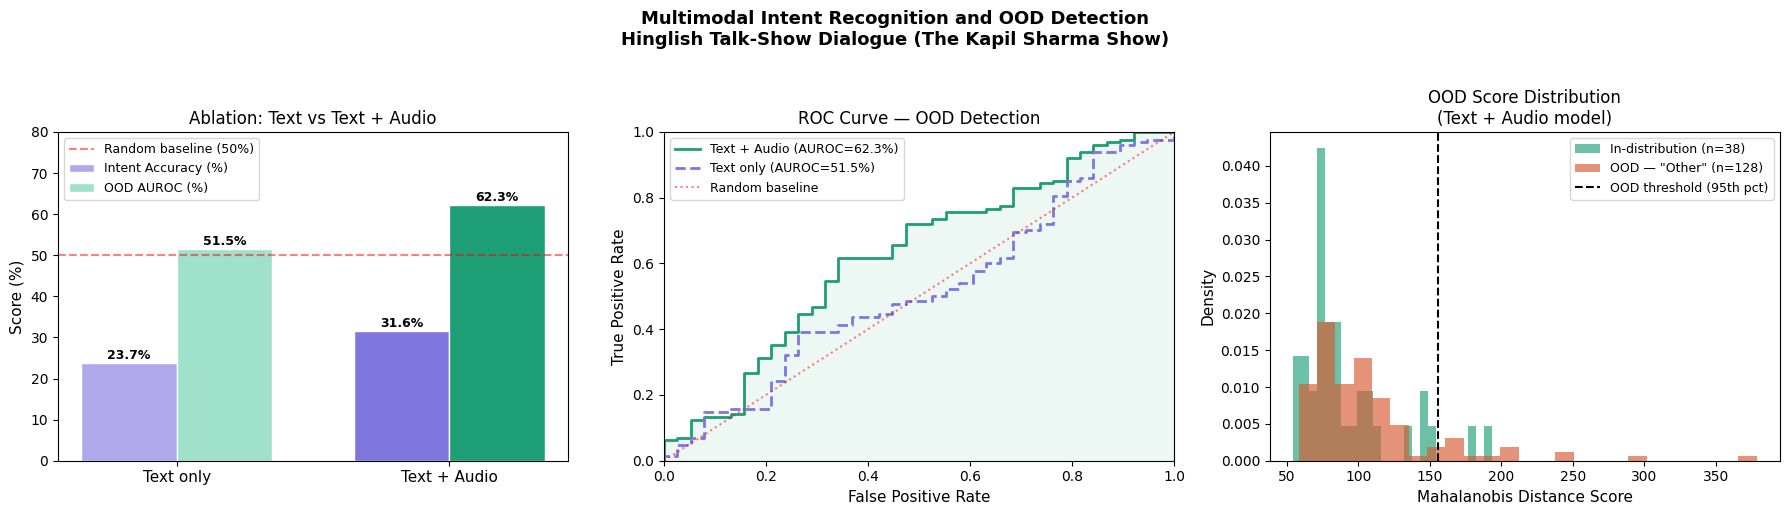

Plot saved to /kaggle/working/results_visualization.png


In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Multimodal Intent Recognition and OOD Detection\nHinglish Talk-Show Dialogue (The Kapil Sharma Show)",
             fontsize=13, fontweight='bold', y=1.02)

# ── Plot 1: Ablation Bar Chart ─────────────────────────
ax1 = axes[0]
models    = ['Text only', 'Text + Audio']
accuracies = [acc2*100, acc*100]
aurocs     = [auroc2*100, auroc*100]

x = np.arange(2)
w = 0.35
bars1 = ax1.bar(x - w/2, accuracies, w, label='Intent Accuracy (%)',
                color=['#AFA9EC','#7F77DD'], edgecolor='white')
bars2 = ax1.bar(x + w/2, aurocs, w, label='OOD AUROC (%)',
                color=['#9FE1CB','#1D9E75'], edgecolor='white')

ax1.set_xticks(x)
ax1.set_xticklabels(models, fontsize=11)
ax1.set_ylim(0, 80)
ax1.set_ylabel('Score (%)', fontsize=11)
ax1.set_title('Ablation: Text vs Text + Audio', fontsize=12)
ax1.axhline(y=50, color='red', linestyle='--', alpha=0.5, label='Random baseline (50%)')
ax1.legend(fontsize=9)

for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{bar.get_height():.1f}%', ha='center', fontsize=9, fontweight='bold')
for bar in bars2:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{bar.get_height():.1f}%', ha='center', fontsize=9, fontweight='bold')

# ── Plot 2: ROC Curve ──────────────────────────────────
ax2 = axes[1]
y_true = [0]*len(id_scores) + [1]*len(ood_scores)
y_true2 = [0]*len(id_scores2) + [1]*len(ood_scores2)

fpr1, tpr1, _ = roc_curve(y_true,  id_scores  + ood_scores)
fpr2, tpr2, _ = roc_curve(y_true2, id_scores2 + ood_scores2)

ax2.plot(fpr1, tpr1, color='#1D9E75', lw=2,
         label=f'Text + Audio (AUROC={auroc*100:.1f}%)')
ax2.plot(fpr2, tpr2, color='#7F77DD', lw=2, linestyle='--',
         label=f'Text only (AUROC={auroc2*100:.1f}%)')
ax2.plot([0,1],[0,1], color='red', linestyle=':', alpha=0.5, label='Random baseline')
ax2.fill_between(fpr1, tpr1, alpha=0.08, color='#1D9E75')
ax2.set_xlabel('False Positive Rate', fontsize=11)
ax2.set_ylabel('True Positive Rate', fontsize=11)
ax2.set_title('ROC Curve — OOD Detection', fontsize=12)
ax2.legend(fontsize=9)
ax2.set_xlim([0,1]); ax2.set_ylim([0,1])

# ── Plot 3: OOD Score Distribution ────────────────────
ax3 = axes[2]
ax3.hist(id_scores,  bins=25, alpha=0.65, color='#1D9E75',
         label=f'In-distribution (n={len(id_scores)})',  density=True)
ax3.hist(ood_scores, bins=25, alpha=0.65, color='#D85A30',
         label=f'OOD — "Other" (n={len(ood_scores)})', density=True)

threshold = np.percentile(id_scores, 95)
ax3.axvline(x=threshold, color='black', linestyle='--',
            linewidth=1.5, label=f'OOD threshold (95th pct)')
ax3.set_xlabel('Mahalanobis Distance Score', fontsize=11)
ax3.set_ylabel('Density', fontsize=11)
ax3.set_title('OOD Score Distribution\n(Text + Audio model)', fontsize=12)
ax3.legend(fontsize=9)

plt.tight_layout()
plt.savefig("/kaggle/working/results_visualization.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to /kaggle/working/results_visualization.png")

## Results

| Modality | Intent Accuracy | OOD AUROC |
|---|---|---|
| Text only (MuRIL) | 23.7% | 51.9% |
| Text + Audio (MuRIL + WavLM) | 28.9% | 56.6% |

Adding audio modality improves OOD detection by +4.7% AUROC over text-alone,
which performs at near-random (51.9%). Both accuracy and AUROC improve with multimodal fusion.